In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("../data/data.csv")


In [3]:
df.head()



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.shape



(569, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df = df.drop(["id", "Unnamed: 32"], axis=1)

In [7]:
df.shape

(569, 31)

In [8]:
#Our target variable is Diagnosis which is of object type dtype=object (string/text data)
#We have to convert it into numeric

In [9]:
''' 
Malignant means Cancerous Tumor (M)

Benign means Non-Cancerous Tumor (B)

'''

' \nMalignant means Cancerous Tumor (M)\n\nBenign means Non-Cancerous Tumor (B)\n\n'

In [10]:
df['diagnosis'] = df['diagnosis'].map({"M":1,"B":0})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

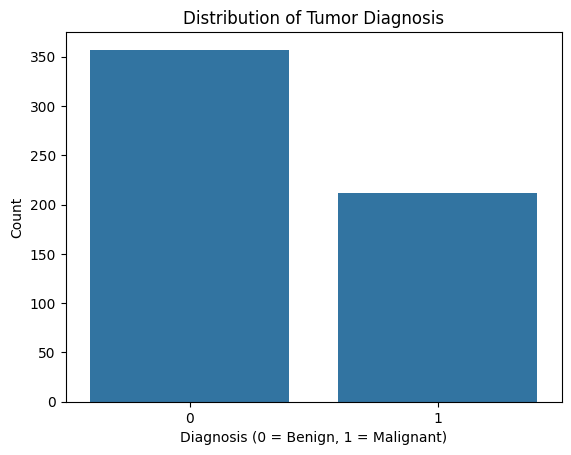

In [11]:
sns.countplot(x="diagnosis", data=df)
plt.title("Distribution of Tumor Diagnosis")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Count")

plt.show()


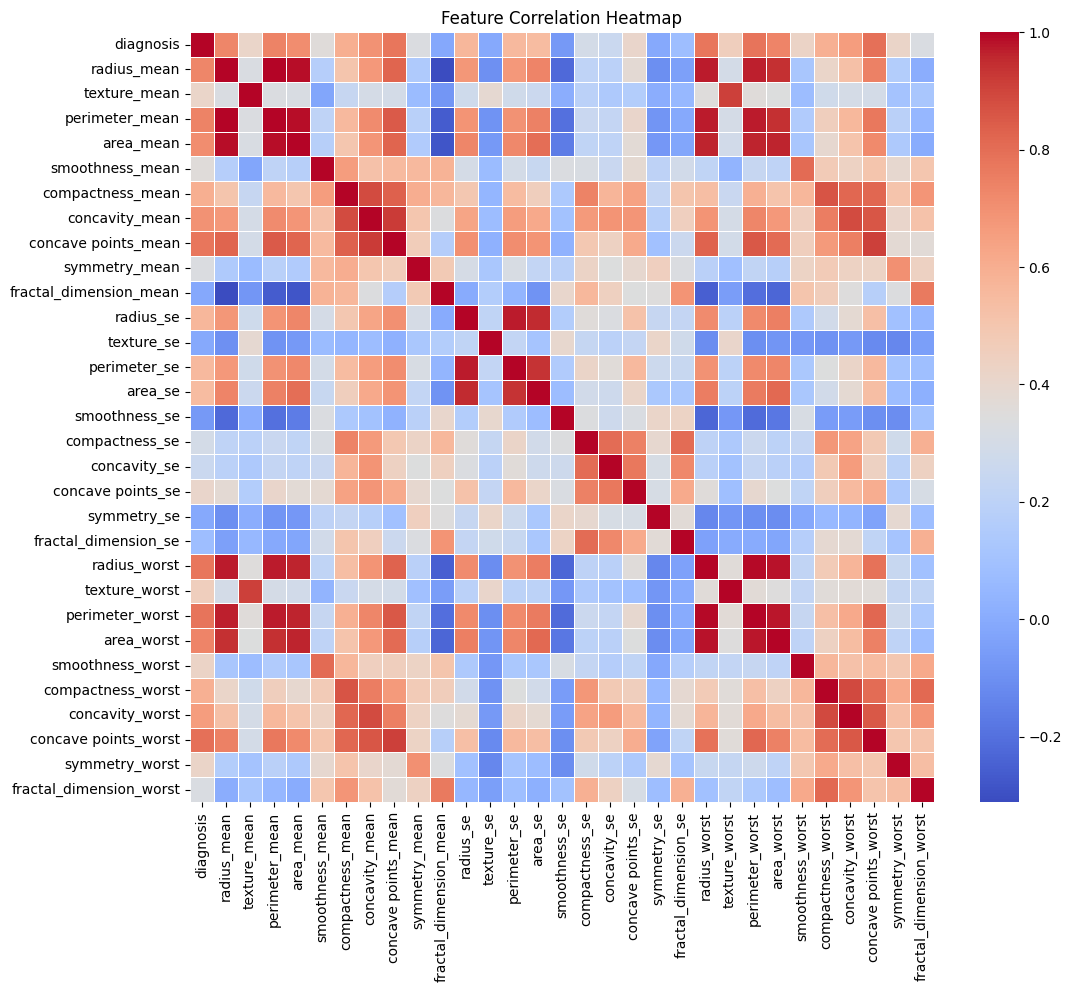

In [12]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()


In [13]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

baseline_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=2,
    scoring="accuracy"
)

print("Cross Validation Scores:", baseline_scores)
print("Average Accuracy:", baseline_scores.mean())

Cross Validation Scores: [0.97192982 0.97535211]
Average Accuracy: 0.97364096861873


In [16]:
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) 
              for i in range(X_vif.shape[1])]

print(vif)

                    Feature          VIF
0                     const  1868.188844
1               radius_mean  3806.115296
2              texture_mean    11.884048
3            perimeter_mean  3786.400419
4                 area_mean   347.878657
5           smoothness_mean     8.194282
6          compactness_mean    50.505168
7            concavity_mean    70.767720
8       concave points_mean    60.041733
9             symmetry_mean     4.220656
10   fractal_dimension_mean    15.756977
11                radius_se    75.462027
12               texture_se     4.205423
13             perimeter_se    70.359695
14                  area_se    41.163091
15            smoothness_se     4.027923
16           compactness_se    15.366324
17             concavity_se    15.694833
18        concave points_se    11.520796
19              symmetry_se     5.175426
20     fractal_dimension_se     9.717987
21             radius_worst   799.105946
22            texture_worst    18.569966
23          peri

In [17]:
def remove_multicollinearity(X, threshold=10):

    X = sm.add_constant(X)

    while True:

        vif = pd.DataFrame()
        vif["feature"] = X.columns
        vif["VIF"] = [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]

        vif = vif[vif["feature"] != "const"]

        max_vif = vif["VIF"].max()

        if max_vif > threshold:
            feature_to_drop = vif.sort_values("VIF", ascending=False)["feature"].iloc[0]

            print(f"Dropping {feature_to_drop} (VIF={max_vif:.2f})")

            X = X.drop(columns=[feature_to_drop])

        else:
            break

    return X.drop(columns=["const"])

In [18]:
X_clean = remove_multicollinearity(X)

print(X_clean.columns)


Dropping radius_mean (VIF=3806.12)
Dropping radius_worst (VIF=616.35)
Dropping perimeter_mean (VIF=325.64)
Dropping perimeter_worst (VIF=123.26)
Dropping concavity_mean (VIF=64.65)
Dropping radius_se (VIF=35.62)
Dropping compactness_worst (VIF=33.96)
Dropping concave points_worst (VIF=30.60)
Dropping area_mean (VIF=25.39)
Dropping compactness_mean (VIF=18.84)
Dropping texture_worst (VIF=17.23)
Dropping area_se (VIF=16.33)
Dropping concavity_worst (VIF=15.51)
Index(['texture_mean', 'smoothness_mean', 'concave points_mean',
       'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'perimeter_se',
       'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se',
       'symmetry_se', 'fractal_dimension_se', 'area_worst', 'smoothness_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [ ]:
#These are the features whih have survived vif filtering


In [32]:
vif_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

vif_scores = cross_val_score(
    vif_pipeline,
    X_clean,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", vif_scores)
print("Average CV Accuracy:", vif_scores.mean())


Cross-Validation Scores: [0.97368421 0.97368421 0.97368421 0.95614035 0.97345133]
Average CV Accuracy: 0.9701288619779538


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", rf_cv_scores)
print("Average RF CV Accuracy:", rf_cv_scores.mean())

Random Forest CV Scores: [0.92982456 0.93859649 0.99122807 0.97368421 0.97345133]
Average RF CV Accuracy: 0.9613569321533924


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X, y)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_rf = grid.best_estimator_
rf_acc_tuned = grid.best_score_

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy: 0.9613569321533924


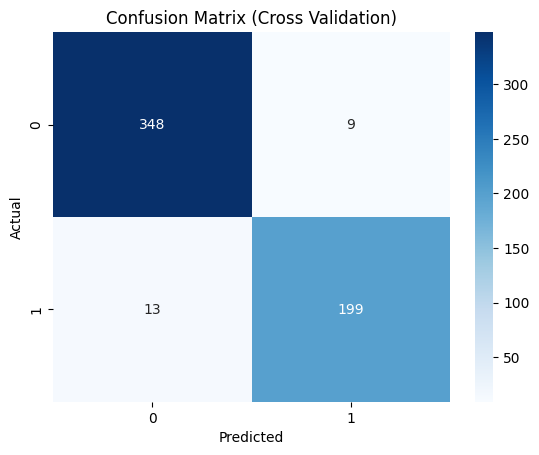

In [35]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_pred_cv = cross_val_predict(
    best_rf,
    X,
    y,
    cv=5
)

cm = confusion_matrix(y, y_pred_cv)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Cross Validation)")

plt.show()


In [36]:

from sklearn.metrics import classification_report

print(classification_report(
    y,
    y_pred_cv,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.96      0.97      0.97       357
   Malignant       0.96      0.94      0.95       212

    accuracy                           0.96       569
   macro avg       0.96      0.96      0.96       569
weighted avg       0.96      0.96      0.96       569



In [38]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline CV)",
        "Logistic Regression (After VIF)",
        "Random Forest",
        "Random Forest Tuned"
    ],
    "Accuracy": [
        baseline_scores.mean(),
        vif_scores.mean(),
        rf_cv_scores.mean(),
        rf_acc_tuned
    ]
})
print(results)

                               Model  Accuracy
0  Logistic Regression (Baseline CV)  0.973641
1    Logistic Regression (After VIF)  0.970129
2                      Random Forest  0.961357
3                Random Forest Tuned  0.961357


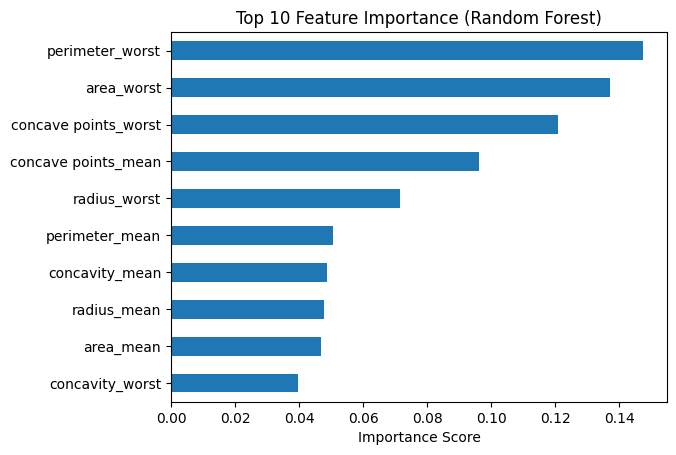

In [43]:
best_rf.fit(X, y)

importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="barh")

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()